In [2]:
import re
import pandas as pd
from collections import Counter
import re


In [3]:
path = '../data/small_samples/nosalary_sample_20k.parquet.gzip'

In [4]:
usdf = pd.read_parquet(path)

In [14]:
usdf.columns

Index(['ID', 'CITY_NAME', 'COUNTY_NAME', 'STATE_NAME', 'NAICS_2022_2',
       'NAICS_2022_2_NAME', 'MIN_EDULEVELS_NAME', 'EMPLOYMENT_TYPE',
       'EMPLOYMENT_TYPE_NAME', 'IS_INTERNSHIP', 'REMOTE_TYPE',
       'REMOTE_TYPE_NAME', 'SKILLS', 'SKILLS_NAME', 'POSTED',
       'LAST_UPDATED_DATE', 'ONET', 'ONET_NAME', 'ONET_2019', 'ONET_2019_NAME',
       'SOC_2021_2_NAME', 'SOC_2021_2', 'MIN_YEARS_EXPERIENCE', 'COMPANY',
       'COMPANY_NAME', 'COMPANY_RAW', 'AI ROLE', 'wfh_wham_prob', 'wfh_wham',
       'YEAR', 'BODY', 'EDU_ASSISTANCE', 'WLB', 'PAID_LEAVE',
       'HEALTH_WELLBEING', 'PARENTAL_LEAVE', 'CULTURE', 'EXPERIENCE_BUCKET',
       'SALARY', 'LOG_SALARY'],
      dtype='object')

In [13]:
usdf['BODY']

82491       Director, Product Management\n\nTurner Broadca...
1917879     Data Warehouse DeveloperArlington,Virginia,Uni...
1224645     Accounting Supervisor (Remote)\n\nCBRE\n\nBrid...
8485630     9857758 Technology Architect II\n\n\t\t\t\t\t\...
11263843    Quality Lab Technician\n\nConfidential Elgin, ...
                                  ...                        
4288073     Claims Manager\n\nEmployer\n    AssuranceAmeri...
10954747    Housekeeping Lead Coordinator\n\nCompany: Fair...
5497352     Job Information\n\nNew York Life Insurance Co ...
5486290     Credentialed Tax Advisor - CPA, Enrolled Agent...
7839349     Back to search\nCare.com\nLooking For A Pet Si...
Name: BODY, Length: 20000, dtype: object

In [17]:


# Filter rows containing the word 'remote' in the 'JOB_DESCRIPTION' column if it is not NA
filtered_rows = usdf.dropna(subset=['BODY'])
filtered_rows = filtered_rows[filtered_rows['BODY'].str.contains(r'\bremote\b', flags=re.IGNORECASE, regex=True)]

# Extract the two words before and after 'remote' in each filtered row
phrases = []
for description in filtered_rows['BODY']:
    words = description.split()
    for i, word in enumerate(words):
        if word.lower() == 'remote':
            if i == 2:
                phrases.append(' '.join(words[i-2:i+4]))
            elif i >= 3:
                phrases.append(' '.join(words[i-3:i+4]))
            elif i == 1:
                phrases.append(' '.join(words[i-1:i+4]))
            elif i == 0:
                phrases.append(' '.join(words[i:i+5]))

# Count the occurrences of each phrase
phrase_counts = Counter(phrases)

# Get the top phrases
top_phrases = phrase_counts.most_common()

# Print the top phrases
for phrase, count in top_phrases:
    print(f'{phrase}: {count}')

COVID-19 Precaution(s): * Remote interview process *: 49
- US - Remote - US -: 32
Remote or Telework - Full: 13
to hiring a Remote Employee for this: 12
well-being; offering a remote work environment and: 12
States of America, Remote - US -: 11
100 Company with Remote Jobs. We are: 11
clinical and administrative, remote and onsite, paid: 11
Project engagements include remote delivery methods and: 10
is listed as remote or hybrid, you'll: 9
Remote - Work at home: 8
team is 100% remote and we work: 8
work solutions including remote options, hybrid work: 7
Job Type Full-time Remote Benefits Pulled from: 7
full-time or part-time REMOTE position. You'll be: 7
do not include remote workers who only: 7
- Florida - Remote | US -: 6
time between both remote and office. Employees: 6
operates in a remote capacity, but you: 6
COVID-19 Precaution(s): * Remote interview process: 5
This is a remote position that can: 5
- Massachusetts - Remote | US -: 5
New York - Remote | US -: 5
applicable for 100%

In [20]:

# list of keywords that suggest remote work
remote_keywords = ['remote', 'work from home', 'virtual position', 'remote position', 'telecommute', 'distributed team']

# Create a new column 'REMOTE_JOB' to flag remote jobs based on the presence of any keywords in 'JOB_DESCRIPTION'
# df['REMOTE_JOB'] = df['JOB_DESCRIPTION'].apply(lambda x: any(keyword in x.lower() for keyword in remote_keywords))

# get the count of remote and non-remote jobs by industry:
# remote_jobs_by_industry = df.groupby(['INDUSTRY', 'REMOTE_JOB']).size().reset_index(name='COUNT')


In [29]:
# Define the regular expression pattern
pattern = r'((?:\w+\s+){{0,4}})({})((?:\s+\w+){{0,4}})'.format('|'.join(remote_keywords))

context_df = pd.DataFrame()

# Apply the regular expression pattern to 'JOB_DESCRIPTION' column and extract the matched strings
context_df['KEYWORD_CONTEXT'] = usdf['BODY'].apply(lambda x: re.findall(pattern, x.lower()))

# Extract the keyword and the word before and after it from the matched strings
context_df['KEYWORD_CONTEXT'] = context_df['KEYWORD_CONTEXT'].apply(lambda x: [' '.join(filter(None, item)).strip() for item in x])



In [30]:

# Remove empty lists from 'KEYWORD_CONTEXT' column
context_df['KEYWORD_CONTEXT'] = context_df['KEYWORD_CONTEXT'].apply(lambda x: x if len(x) > 0 else None)
# Explode the 'KEYWORD_CONTEXT' column to have one phrase per row
context_df = context_df.explode('KEYWORD_CONTEXT')

In [27]:
context_df[context_df['KEYWORD_CONTEXT'].notnull()]

,KEYWORD_CONTEXT
1224645,"[remote, remote, remote, remote, be performed ..."
8485630,[on experience\n\n\t\t\t\t\t\t\n\n\t\t\t\t\t\n...
4176771,"[is a remote role, opportunity to work from..."
8042076,[remote \n\n\t\t\t\t\t\n\n\t\t\t\t\t\t\n\n\t\t...
10182767,"[flexibility to telecommute, telecommute, uni..."
...,...
8956915,[remote]
2665397,"[remote, remote virtual, 06608 work remote]"
8622267,"[nd 58103 remote, eligible for remote, work ..."
3374747,[remote]


# Label Remote Keywords

In [63]:
remote_keywords = [
    "fully remote", "100% remote", "work from home", "remote role", "work remotely", 
    "remote eligible", "open to remote", "remote work environment", "remote work policy", 
    "remote and onsite", "virtual role", "remote first", "home office", "telecommute", 
    "distributed team", "remote-first", "remote-friendly", "remote options", "virtual work", "work from home", 
    "remote position", "wfh", "Remote - us", "telework", "home office", "(remote)", "remote work flexibility", "remote work: hybrid", 
    "remote: yes", "location: remote", "remote usa", "remote flexibility", "(remote", "- remote", "remote-flexibility", 
    "remote,", "\nremote\n", "\n remote \n", "remotely", "us-remote", "remote work eligible", "remote - united states", 
    "remote - work at home", "can be remote", "remote within the us", "remote in north america", "remote available" ", remote", 
    "remote full-time", "us remote", "#li-remote", "open to remote"
    
]
hybrid_keywords = [
    "hybrid work", "split time between office and remote", "office and remote options", 
    "partially remote", "hybrid position", "3 days remote", "hybrid workplace", 
    "some remote days", "in-office and remote", "hybrid onsite", "remote or in-office", "work-from-home days", "mix of working in the office and from home", "#li-hybrid", "hybrid remote"
]
exclusions = [
    "not considering remote", "in-office only", 
    "remote monitoring", "remote sensing", "remote access systems", "remote control", 
    "remote diagnostics", "remote delivery", "#li-onsite", "onsite job", "work from home not available", "telework:no", 
    "remote: no", "100% on-site", "work at home option: No",
    "remotely: no", "remote: n", "remotely: n", "telework: no", "remote: * no", "remotely: * no"
    "remotely piloted", "data remotely", "remote type on-site", "interviewed remotely", "work remotely: * no", "remotely piloted", 
    "remote desktop", "must be able to work on-site", "not applicable for 100% remote", "remote testing", "remotely upgrading", "remote usability",
    "remote site", "remote machine", "remote iot", "no remote", "work remotely no", "remotely:no", "remotely? n", "remotely no", "remote areas", 
    "remote access", "remote position? no", "remotely tucked away", "supporting remote", "remotely sensed"
]

#, "remote interview process"

In [64]:
def clean_text(text):
    if isinstance(text, str):  # Ensure the value is a string
        text = text.strip()  # Remove leading and trailing spaces
        text = ' '.join(text.split())  # Replace multiple spaces with a single space
        text = text.replace('\n', ' ')  # Remove newline characters
    return text

# Apply the cleaning function to the Remote_KW column
usdf['BODY'] = usdf['BODY'].apply(clean_text)

In [65]:
def label_remote_hybrid(row):
    body = row["BODY"] 
    if not body:  # Check if body is empty or None
        return 0
    if any(kw in body for kw in exclusions):
        return 0 
    elif any(kw in body for kw in remote_keywords):
        return 1    
    elif any(kw in body for kw in hybrid_keywords):
        return 1
    return 0

# Apply the labeling function
usdf["Remote_KW"] = usdf.apply(label_remote_hybrid, axis=1)

# Display the labeled DataFrame
usdf.head()

,ID,CITY_NAME,COUNTY_NAME,STATE_NAME,NAICS_2022_2,NAICS_2022_2_NAME,MIN_EDULEVELS_NAME,EMPLOYMENT_TYPE,EMPLOYMENT_TYPE_NAME,IS_INTERNSHIP,...,EDU_ASSISTANCE,WLB,PAID_LEAVE,HEALTH_WELLBEING,PARENTAL_LEAVE,CULTURE,EXPERIENCE_BUCKET,SALARY,LOG_SALARY,Remote_KW
82491,bc914ffb88715afe9617030597e2414a353d3756,"Atlanta, GA","Fulton, GA",Georgia,51,Information,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,6-10 years,NaN,NaN,0
1917879,37cc49b2439d744840e77f15916031318c4e56e8,"Arlington, VA","Arlington, VA",Virginia,54,"Professional, Scientific, and Technical Services",Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,3-5 years,NaN,NaN,0
1224645,225fd4922d608f72c1e9cde1c7162987c0ad80f9,"Bridgeport, CT","Fairfield, CT",Connecticut,53,Real Estate and Rental and Leasing,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,3-5 years,NaN,NaN,1
8485630,b5fc6e56ce95b53800245604bd64ab84f598b2b3,"South San Francisco, CA","San Mateo, CA",California,54,"Professional, Scientific, and Technical Services",Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,6-10 years,NaN,NaN,0
11263843,78fd685731a15f1459f95c65f55ad608f4dc57b0,"Hoffman, IL","Clinton, IL",Illinois,31,Manufacturing,No Education Listed,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,3-5 years,NaN,NaN,0


In [122]:
usdf.Remote_KW.value_counts()

Remote_KW
0    16874
1     3126
Name: count, dtype: int64

## WHAM Validation

In [9]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

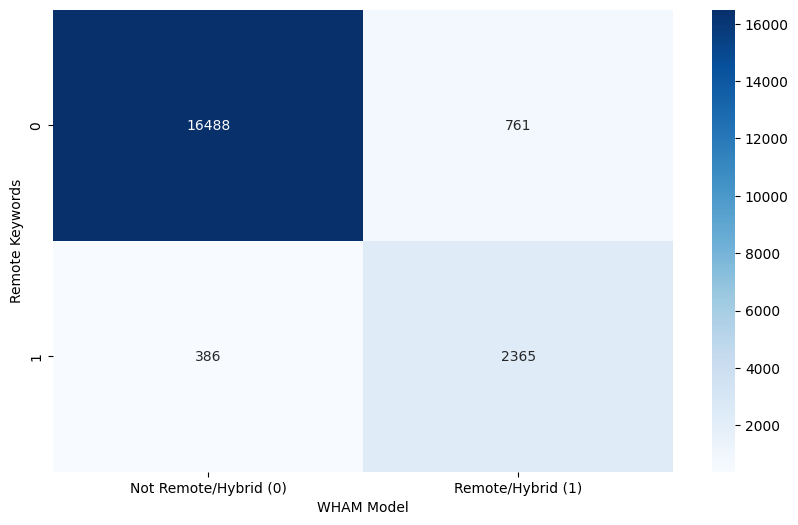

In [73]:


# Pivot the data to create a confusion matrix format
# cf_df = usdf[usdf['REMOTE_TYPE_NAME']!='[None]']
confusion_matrix = usdf.groupby(['Remote_KW', 'wfh_wham']).size().unstack().fillna(0)
confusion_matrix.columns = ['Not Remote/Hybrid (0)', 'Remote/Hybrid (1)']
confusion_matrix.index.name = 'Remote_KW'

# Plot the confusion matrix
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix, annot=True, fmt='g', cmap='Blues')
plt.ylabel('Remote Keywords')
plt.xlabel('WHAM Model')
plt.show()


In [82]:
confusion_matrix

,Not Remote/Hybrid (0),Remote/Hybrid (1)
Remote_KW,,
0,15959,1002
1,915,2124


In [74]:
confusion_matrix

,Not Remote/Hybrid (0),Remote/Hybrid (1)
Remote_KW,,
0,15953,987
1,921,2139


In [57]:
confusion_matrix

,Not Remote/Hybrid (0),Remote/Hybrid (1)
Remote_KW,,
0,16096,1359
1,778,1767


In [66]:
# Calculate metrics
y_true = usdf['Remote_KW']
y_pred = usdf['wfh_wham']
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Print the metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.94
Precision: 0.76
Recall: 0.86
F1 Score: 0.80


In [40]:
# Calculate metrics
y_true = usdf['Remote_KW']
y_pred = usdf['wfh_wham']
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Print the metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.94
Precision: 0.76
Recall: 0.85
F1 Score: 0.80


In [26]:
# Calculate metrics
y_true = usdf['Remote_KW']
y_pred = usdf['wfh_wham']
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Print the metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.94
Precision: 0.76
Recall: 0.84
F1 Score: 0.80


In [125]:
# Calculate metrics
y_true = usdf['Remote_KW']
y_pred = usdf['wfh_wham']
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Print the metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.92
Precision: 0.73
Recall: 0.74
F1 Score: 0.74


In [118]:
# Calculate metrics
y_true = usdf['Remote_KW']
y_pred = usdf['wfh_wham']
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Print the metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.92
Precision: 0.74
Recall: 0.74
F1 Score: 0.74


In [114]:
# Calculate metrics
y_true = usdf['Remote_KW']
y_pred = usdf['wfh_wham']
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Print the metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.92
Precision: 0.74
Recall: 0.74
F1 Score: 0.74


In [102]:
# Calculate metrics
y_true = usdf['Remote_KW']
y_pred = usdf['wfh_wham']
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Print the metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.92
Precision: 0.74
Recall: 0.74
F1 Score: 0.74


In [93]:
# Calculate metrics
y_true = usdf['Remote_KW']
y_pred = usdf['wfh_wham']
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Print the metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.91
Precision: 0.74
Recall: 0.70
F1 Score: 0.72


In [90]:
# Calculate metrics
y_true = usdf['Remote_KW']
y_pred = usdf['wfh_wham']
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Print the metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.91
Precision: 0.70
Recall: 0.70
F1 Score: 0.70


In [83]:
# Calculate metrics
y_true = usdf['Remote_KW']
y_pred = usdf['wfh_wham']
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Print the metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.90
Precision: 0.68
Recall: 0.70
F1 Score: 0.69


In [75]:
# Calculate metrics
y_true = usdf['Remote_KW']
y_pred = usdf['wfh_wham']
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Print the metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.90
Precision: 0.68
Recall: 0.70
F1 Score: 0.69


In [67]:
# Calculate metrics
y_true = usdf['Remote_KW']
y_pred = usdf['wfh_wham']
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Print the metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.89
Precision: 0.60
Recall: 0.69
F1 Score: 0.64


In [11]:
for i, row in usdf[(usdf['Remote_KW'] == 0)&(usdf['wfh_wham']==1)].iterrows():
    print(row['BODY'])
    print('---')

Director, Analytics CyncHealth - La Vista, NE La Vista, NE Position Summary: The Director of Analytics will lead the development of analytical data from CyncHealth participants and affiliates and translate it into useful/actionable knowledge in the hands of clinicians, assist participants in translating knowledge into meaningful improvement initiatives. Essential Job Responsibilities: Serve as a SME for data analytics both internally and externally. Support academic research and represent CyncHealth. Set initiatives for Analytics department with a focus on optimizing for both current and future business needs. Drive broad organizational engagement and alignment in digital data and analytics initiatives, experiences that matter most to consumers, customers, associates and in line with our business strategies. Ideate, prioritize, and deliver on analytical portfolio investments to ensure Business Value/Outcomes are realized based on prioritized business needs. Ability to design public hea

In [57]:
for i, row in usdf[(usdf['Remote_KW'] == 1)&(usdf['wfh_wham']==0)].iterrows():
    print(row['BODY'])
    print('---')

Job Details Posted 2 days ago Options Document Management Specialist I 22218722 West Coast Consulting LLC Little Rock, AR $17 - $18 Contract: W2, 12 Month(s) Skills OCRSCANNERADMINECM Job Description Hi, Let me know if you are available for this position. If you have any friends looking for job change share this job with them as well. Looking forward for your reply!!! JOB: Document Management Specialist I 22218722 LOCATION: Little Rock AR 72202 CLIENT- BCBS-Arkansas Has worked in Administrative roles before long term MUST Handled large volumes of emails MS Office, databases (data entry) OCR, scanning, processed receipts ECM (content management software) . The Document Management Specialist I processes a high volume of incoming mail daily as well as internal documentation. The Specialist assists in overseeing the enterprise s documents and maintaining a paperless and secure work environment for our internal staff. Electronic means of delivery are established (workflows) for most forms o

In [68]:
usdf

,ID,CITY_NAME,COUNTY_NAME,STATE_NAME,NAICS_2022_2,NAICS_2022_2_NAME,MIN_EDULEVELS_NAME,EMPLOYMENT_TYPE,EMPLOYMENT_TYPE_NAME,IS_INTERNSHIP,...,EDU_ASSISTANCE,WLB,PAID_LEAVE,HEALTH_WELLBEING,PARENTAL_LEAVE,CULTURE,EXPERIENCE_BUCKET,SALARY,LOG_SALARY,Remote_KW
82491,bc914ffb88715afe9617030597e2414a353d3756,"Atlanta, GA","Fulton, GA",Georgia,51,Information,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,6-10 years,NaN,NaN,0
1917879,37cc49b2439d744840e77f15916031318c4e56e8,"Arlington, VA","Arlington, VA",Virginia,54,"Professional, Scientific, and Technical Services",Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,3-5 years,NaN,NaN,0
1224645,225fd4922d608f72c1e9cde1c7162987c0ad80f9,"Bridgeport, CT","Fairfield, CT",Connecticut,53,Real Estate and Rental and Leasing,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,3-5 years,NaN,NaN,1
8485630,b5fc6e56ce95b53800245604bd64ab84f598b2b3,"South San Francisco, CA","San Mateo, CA",California,54,"Professional, Scientific, and Technical Services",Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,6-10 years,NaN,NaN,0
11263843,78fd685731a15f1459f95c65f55ad608f4dc57b0,"Hoffman, IL","Clinton, IL",Illinois,31,Manufacturing,No Education Listed,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,3-5 years,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4288073,9ff49565e3276357d9def2c101ead85e8602be20,"Tampa, FL","Hillsborough, FL",Florida,99,Unclassified Industry,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,6-10 years,112499.0,11.630700,0
10954747,252ec620cb2f86a8a888d60cf162832168458546,"Santa Monica, CA","Los Angeles, CA",California,99,Unclassified Industry,High school or GED,1,Full-time (> 32 hours),False,...,False,False,False,False,False,True,None Listed,53040.0,10.878802,0
5497352,6294965c51aa6e73a7abce4e82a33835b2137b6d,"New York, NY","New York, NY",New York,52,Finance and Insurance,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,1-2 years,NaN,NaN,1
5486290,eac6be582f7d0fb9a0f9c6a54d2acfc9bac308c9,"Newark, NJ","Essex, NJ",New Jersey,51,Information,No Education Listed,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,3-5 years,NaN,NaN,0


# Even Sample

In [69]:
even_sample = pd.read_parquet('../data/small_samples/salary_sample_2018_2023.parquet.gzip')

In [70]:

# Apply the labeling function
even_sample["Remote_KW"] = even_sample.apply(label_remote_hybrid, axis=1)



,ID,CITY_NAME,COUNTY_NAME,STATE_NAME,NAICS_2022_2,NAICS_2022_2_NAME,MIN_EDULEVELS_NAME,EMPLOYMENT_TYPE,EMPLOYMENT_TYPE_NAME,IS_INTERNSHIP,...,EDU_ASSISTANCE,WLB,PAID_LEAVE,HEALTH_WELLBEING,PARENTAL_LEAVE,CULTURE,EXPERIENCE_BUCKET,SALARY,LOG_SALARY,Remote_KW
82491,bc914ffb88715afe9617030597e2414a353d3756,"Atlanta, GA","Fulton, GA",Georgia,51,Information,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,6-10 years,NaN,NaN,0
1917879,37cc49b2439d744840e77f15916031318c4e56e8,"Arlington, VA","Arlington, VA",Virginia,54,"Professional, Scientific, and Technical Services",Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,3-5 years,NaN,NaN,0
1224645,225fd4922d608f72c1e9cde1c7162987c0ad80f9,"Bridgeport, CT","Fairfield, CT",Connecticut,53,Real Estate and Rental and Leasing,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,3-5 years,NaN,NaN,1
8485630,b5fc6e56ce95b53800245604bd64ab84f598b2b3,"South San Francisco, CA","San Mateo, CA",California,54,"Professional, Scientific, and Technical Services",Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,6-10 years,NaN,NaN,0
11263843,78fd685731a15f1459f95c65f55ad608f4dc57b0,"Hoffman, IL","Clinton, IL",Illinois,31,Manufacturing,No Education Listed,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,3-5 years,NaN,NaN,0


In [71]:
even_sample.groupby(['YEAR', 'Remote_KW']).size().reset_index(name='COUNT')

,YEAR,Remote_KW,COUNT
0,2018,0,1308
1,2018,1,57
2,2019,0,1456
3,2019,1,120
4,2020,0,1449
5,2020,1,535
6,2021,0,2089
7,2021,1,1312
8,2022,0,3673
9,2022,1,1347


In [72]:
even_sample.to_parquet('../data/small_samples/salary_sample_2018_2023.parquet.gzip', index=False)